<a href="https://colab.research.google.com/github/mukund1040/Data-Analytics-Projects/blob/main/02-Sales-Data-Analysis/Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Data Analysis

## Project Objective

The objective of this project is to analyze sales data
and identify important sales trends, profitable products,
customer segments, and regional performance.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
import os

for root, dirs, files in os.walk("/"):
    if "Sample - Superstore.csv" in files:
        print(os.path.join(root, "Sample - Superstore.csv"))

/content/Sample - Superstore.csv


In [9]:
df = pd.read_csv("Sample - Superstore.csv" ,  encoding="latin1")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# 01.Understand the Data

### Find the size of the dataset

In [10]:
df.shape

(9994, 21)

### all column names

In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Understand data types and missing values

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Check missing values

In [13]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Check duplicate rows

In [14]:
df.duplicated().sum()

np.int64(0)

### Basic statistics

In [15]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# 02. Understand the business

### total sales.

In [16]:
df["Sales"].sum()

np.float64(2297200.8603000003)

### total profit.

In [17]:
df["Profit"].sum()

np.float64(286397.0217)

### total quantity sold.

In [18]:
df["Quantity"].sum()

np.int64(37873)

### number of unique orders.

In [19]:
df["Order ID"].nunique()

5009

## 03 Data Cleaning & Date Conversion

Check the current data types

In [20]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


Convert Order Date to datetime

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Date"].dtype

dtype('<M8[ns]')

Convert Ship Date

In [23]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


## 04 Create useful date columns

Create Year

In [25]:
df["Year"] = df["Order Date"].dt.year
df["Year"].unique()

array([2016, 2015, 2014, 2017], dtype=int32)

Create Month

In [28]:
df["Month"] = df["Order Date"].dt.month
df["Month"].unique()

array([11,  6, 10,  4, 12,  5,  8,  7,  9,  1,  3,  2], dtype=int32)

 Create Month Name

In [29]:
df["Month_Name"] = df["Order Date"].dt.month_name()

In [30]:
df[["Order Date", "Year", "Month", "Month_Name"]].head()

,Order Date,Year,Month,Month_Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


## 05 Calculate shipping time

In [31]:
df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [34]:
df[["Order Date", "Ship Date", "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


## 06 Check whether our new columns are correct

In [35]:
df[["Year", "Month", "Month_Name", "Shipping_Days"]].describe()

,Year,Month,Shipping_Days
count,9994.000000,9994.000000,9994.000000
mean,2015.722233,7.809686,3.958175
std,1.123555,3.284654,1.747567
min,2014.000000,1.000000,0.000000
25%,2015.000000,5.000000,3.000000
50%,2016.000000,9.000000,4.000000
75%,2017.000000,11.000000,5.000000
max,2017.000000,12.000000,7.000000


In [36]:
df["Shipping_Days"].min(), df["Shipping_Days"].max()

(0, 7)

## 07 Analyze Sales by Year

Calculate yearly sales

In [37]:
yearly_sales = df.groupby("Year")["Sales"].sum()

yearly_sales

,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


Visualize yearly sales

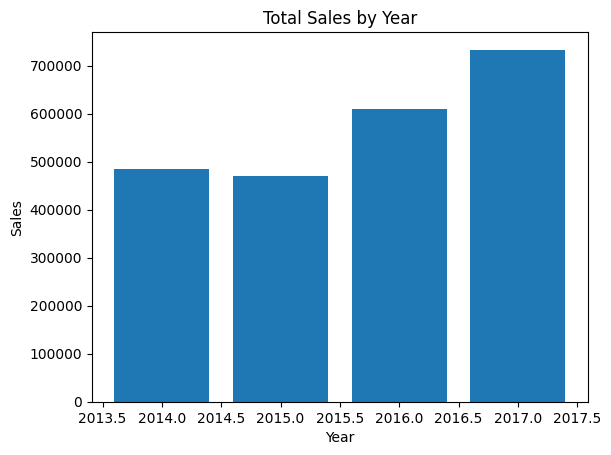

In [38]:
plt.bar(yearly_sales.index, yearly_sales.values)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

Find the best year

In [39]:
yearly_sales.idxmax()

np.int32(2017)

the sales amount for that year.

In [40]:
yearly_sales.max()

733215.2552

## 08 Analyze Sales by Category

In [41]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


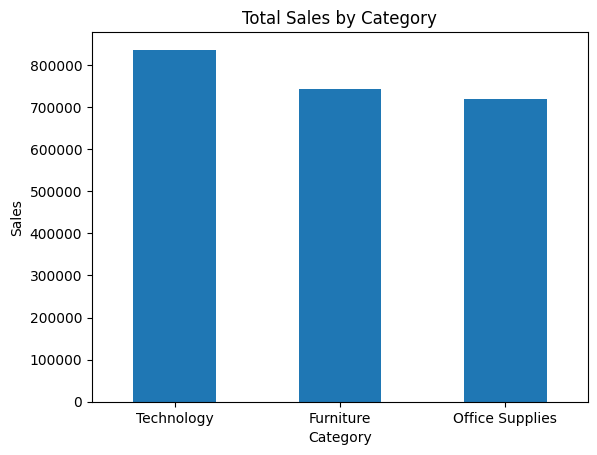

In [42]:
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

find the best category:

In [43]:
category_sales.idxmax()

'Technology'

## 09 Analyze Sales by Sub-Category

In [44]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

subcategory_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


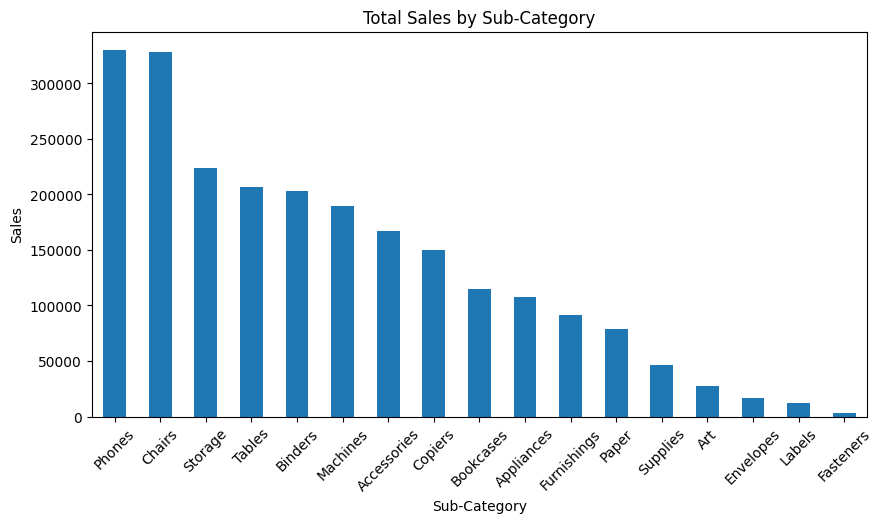

In [45]:
subcategory_sales.plot(kind="bar", figsize=(10,5))

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Find the top sub-category:

In [46]:
subcategory_sales.idxmax()

'Phones'

## 10 Analyze Sales by Region

Which region generates the most sales?

In [47]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


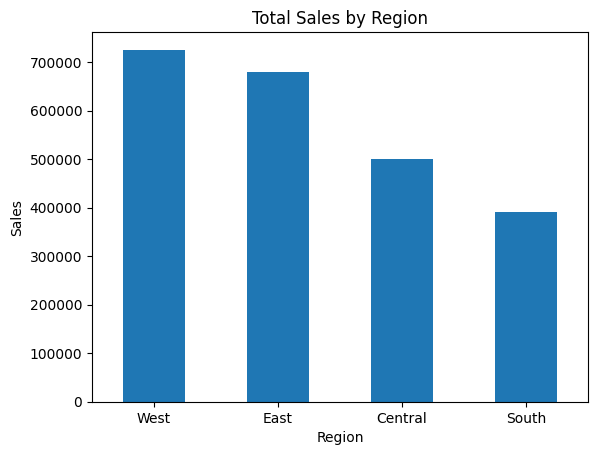

In [48]:
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()